# EDA

In [1]:
!pip install pandas openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
data = pd.read_excel("195_final_cleaned_dataset.xlsx")
data

,Country,Year,PM25,LifeExp,GDP,HealthExp,log_PM25,log_GDP,log_HealthExp
0,Afghanistan,2020,46.087094,61.454,2561.981761,401.163333,3.830533,7.848536,5.994369
1,Afghanistan,2019,58.330872,62.941,2583.485332,383.164896,4.066131,7.856895,5.948465
2,Afghanistan,2018,67.227177,62.443,2432.276701,345.587947,4.208078,7.796583,5.845247
3,Afghanistan,2017,65.862347,62.406,2335.795862,294.796437,4.187567,7.756108,5.686285
4,Afghanistan,2016,72.765910,62.646,2213.181441,261.566867,4.287248,7.702186,5.566690
...,...,...,...,...,...,...,...,...,...
3411,Zimbabwe,2014,23.429253,58.106,3903.427977,203.300574,3.153985,8.269610,5.314686
3412,Zimbabwe,2013,22.598401,56.842,3783.946337,173.586892,3.117879,8.238523,5.156678
3413,Zimbabwe,2012,23.539528,55.386,3472.485720,156.086614,3.158681,8.152626,5.050411
3414,Zimbabwe,2011,23.616283,53.911,3047.317089,161.209011,3.161936,8.022017,5.082702


In [4]:
data.shape

(3416, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3416 entries, 0 to 3415
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        3416 non-null   object 
 1   Year           3416 non-null   int64  
 2   PM25           3416 non-null   float64
 3   LifeExp        3416 non-null   float64
 4   GDP            3416 non-null   float64
 5   HealthExp      3416 non-null   float64
 6   log_PM25       3416 non-null   float64
 7   log_GDP        3416 non-null   float64
 8   log_HealthExp  3416 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 240.3+ KB


In [6]:
data.describe()

,Year,PM25,LifeExp,GDP,HealthExp,log_PM25,log_GDP,log_HealthExp
count,3416.000000,3416.000000,3416.000000,3416.000000,3416.000000,3416.000000,3416.000000,3416.000000
mean,2010.057377,26.622573,70.151098,17988.660816,1196.890606,3.094571,9.158679,6.278487
std,6.048529,17.193630,8.971419,20755.225363,1516.699738,0.613234,1.209935,1.377612
min,2000.000000,4.895181,14.665000,471.967330,10.112074,1.588251,6.156910,2.313730
25%,2005.000000,14.448575,64.352750,3601.222684,170.497458,2.670595,8.189027,5.138720
50%,2010.000000,21.702285,71.774000,10287.077455,583.602308,3.077418,9.238644,6.369220
75%,2015.000000,32.442262,76.975152,25487.571157,1608.382259,3.479462,10.145944,7.382981
max,2020.000000,107.144665,85.257000,180939.439450,11648.495309,4.674180,12.105918,9.362932


In [11]:
# checking how the columns correlate with each other
original_cols_of_interest = ["Country", "Year", "PM25", "LifeExp", "GDP", "HealthExp"]
data[original_cols_of_interest].corr(numeric_only=True)

,Year,PM25,LifeExp,GDP,HealthExp
Year,1.000000,-0.058601,0.194214,0.154969,0.208203
PM25,-0.058601,1.000000,-0.379284,-0.137080,-0.368114
LifeExp,0.194214,-0.379284,1.000000,0.641920,0.661634
GDP,0.154969,-0.137080,0.641920,1.000000,0.793742
HealthExp,0.208203,-0.368114,0.661634,0.793742,1.000000


array([[<Axes: xlabel='Year', ylabel='Year'>,
        <Axes: xlabel='PM25', ylabel='Year'>,
        <Axes: xlabel='LifeExp', ylabel='Year'>,
        <Axes: xlabel='GDP', ylabel='Year'>,
        <Axes: xlabel='HealthExp', ylabel='Year'>],
       [<Axes: xlabel='Year', ylabel='PM25'>,
        <Axes: xlabel='PM25', ylabel='PM25'>,
        <Axes: xlabel='LifeExp', ylabel='PM25'>,
        <Axes: xlabel='GDP', ylabel='PM25'>,
        <Axes: xlabel='HealthExp', ylabel='PM25'>],
       [<Axes: xlabel='Year', ylabel='LifeExp'>,
        <Axes: xlabel='PM25', ylabel='LifeExp'>,
        <Axes: xlabel='LifeExp', ylabel='LifeExp'>,
        <Axes: xlabel='GDP', ylabel='LifeExp'>,
        <Axes: xlabel='HealthExp', ylabel='LifeExp'>],
       [<Axes: xlabel='Year', ylabel='GDP'>,
        <Axes: xlabel='PM25', ylabel='GDP'>,
        <Axes: xlabel='LifeExp', ylabel='GDP'>,
        <Axes: xlabel='GDP', ylabel='GDP'>,
        <Axes: xlabel='HealthExp', ylabel='GDP'>],
       [<Axes: xlabel='Year', ylabel='

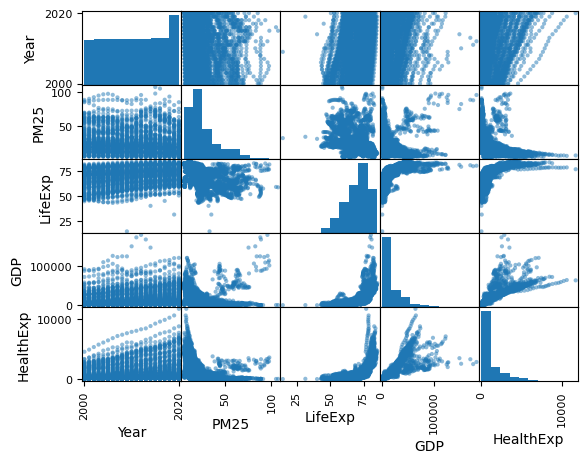

In [8]:
# getting a better look at the correlations using visuals
pd.plotting.scatter_matrix(data[original_cols_of_interest])

It seems like there are some exponential relationships. Using log data to examine those further.

In [9]:
# looking at correlations for log relationships
log_cols_of_interest = ["Year", "log_PM25", "LifeExp", "log_GDP", "log_HealthExp"]
data[log_cols_of_interest].corr(numeric_only=True)

,Year,log_PM25,LifeExp,log_GDP,log_HealthExp
Year,1.000000,-0.086441,0.194214,0.202078,0.221995
log_PM25,-0.086441,1.000000,-0.427523,-0.417979,-0.532178
LifeExp,0.194214,-0.427523,1.000000,0.823555,0.830487
log_GDP,0.202078,-0.417979,0.823555,1.000000,0.945956
log_HealthExp,0.221995,-0.532178,0.830487,0.945956,1.000000


array([[<Axes: xlabel='Year', ylabel='Year'>,
        <Axes: xlabel='log_PM25', ylabel='Year'>,
        <Axes: xlabel='LifeExp', ylabel='Year'>,
        <Axes: xlabel='log_GDP', ylabel='Year'>,
        <Axes: xlabel='log_HealthExp', ylabel='Year'>],
       [<Axes: xlabel='Year', ylabel='log_PM25'>,
        <Axes: xlabel='log_PM25', ylabel='log_PM25'>,
        <Axes: xlabel='LifeExp', ylabel='log_PM25'>,
        <Axes: xlabel='log_GDP', ylabel='log_PM25'>,
        <Axes: xlabel='log_HealthExp', ylabel='log_PM25'>],
       [<Axes: xlabel='Year', ylabel='LifeExp'>,
        <Axes: xlabel='log_PM25', ylabel='LifeExp'>,
        <Axes: xlabel='LifeExp', ylabel='LifeExp'>,
        <Axes: xlabel='log_GDP', ylabel='LifeExp'>,
        <Axes: xlabel='log_HealthExp', ylabel='LifeExp'>],
       [<Axes: xlabel='Year', ylabel='log_GDP'>,
        <Axes: xlabel='log_PM25', ylabel='log_GDP'>,
        <Axes: xlabel='LifeExp', ylabel='log_GDP'>,
        <Axes: xlabel='log_GDP', ylabel='log_GDP'>,
        <

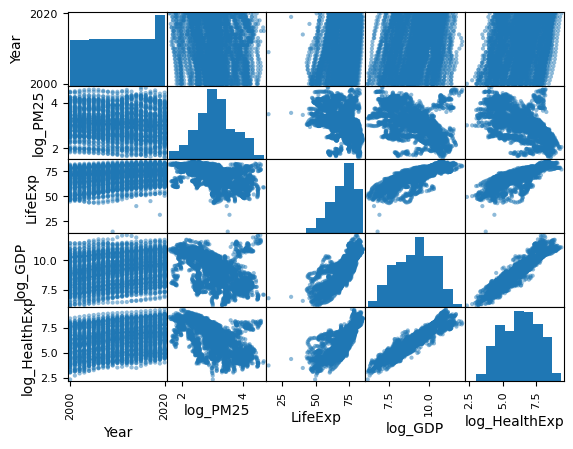

In [10]:
pd.plotting.scatter_matrix(data[log_cols_of_interest])

From the matrix above, it is apparent that PM2.5 (explanatory variable) is moderately associated with lower life expectancy (responding variable) and GDP. 

In [13]:
data

,Country,Year,PM25,LifeExp,GDP,HealthExp,log_PM25,log_GDP,log_HealthExp
0,Afghanistan,2020,46.087094,61.454,2561.981761,401.163333,3.830533,7.848536,5.994369
1,Afghanistan,2019,58.330872,62.941,2583.485332,383.164896,4.066131,7.856895,5.948465
2,Afghanistan,2018,67.227177,62.443,2432.276701,345.587947,4.208078,7.796583,5.845247
3,Afghanistan,2017,65.862347,62.406,2335.795862,294.796437,4.187567,7.756108,5.686285
4,Afghanistan,2016,72.765910,62.646,2213.181441,261.566867,4.287248,7.702186,5.566690
...,...,...,...,...,...,...,...,...,...
3411,Zimbabwe,2014,23.429253,58.106,3903.427977,203.300574,3.153985,8.269610,5.314686
3412,Zimbabwe,2013,22.598401,56.842,3783.946337,173.586892,3.117879,8.238523,5.156678
3413,Zimbabwe,2012,23.539528,55.386,3472.485720,156.086614,3.158681,8.152626,5.050411
3414,Zimbabwe,2011,23.616283,53.911,3047.317089,161.209011,3.161936,8.022017,5.082702


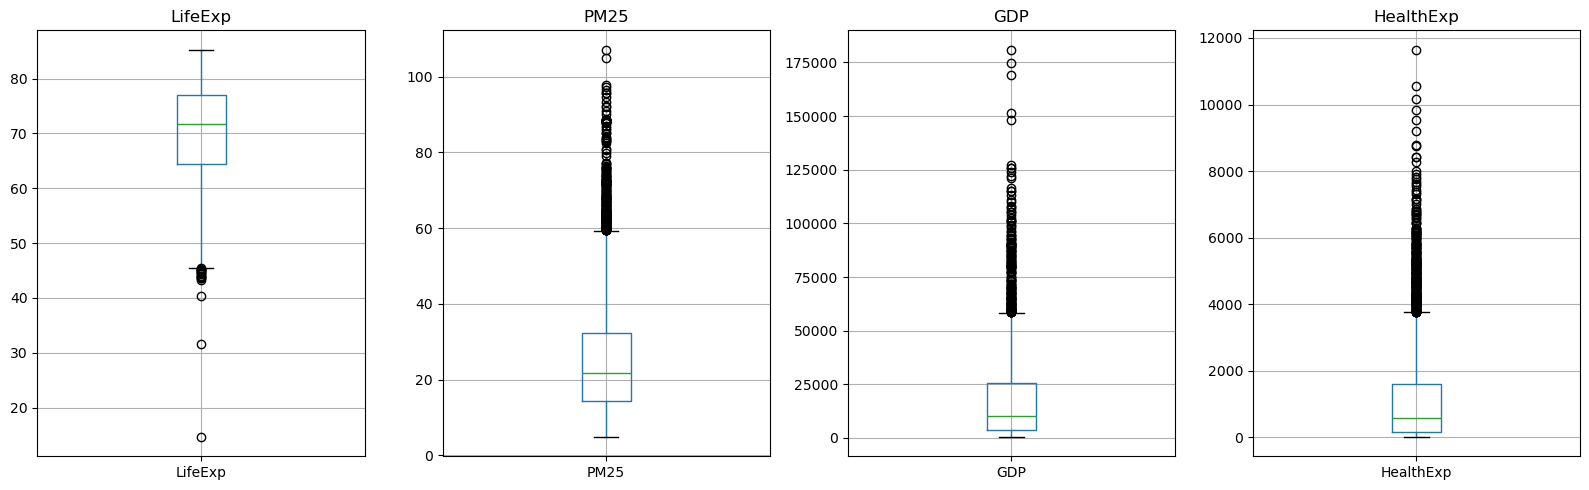

In [27]:
# examining distributions of each variable
box_plots_cols = ['LifeExp', 'PM25', 'GDP', 'HealthExp']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, box_plots_cols):
    data.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [14]:
# Do the countries with the worst air quality also have the lowest life expectancy

# Top 35 countries with worst air pollution
country_PM25 = data.groupby("Country")["PM25"].mean().to_frame()
top_worst_air_quality = country_PM25.sort_values(by="PM25", ascending=False).head(35)

# Top 35 countries with lowest life expectancy
country_LifeExp = data.groupby("Country")["LifeExp"].mean().to_frame()
top_lowest_life_exp = country_LifeExp.sort_values(by="LifeExp", ascending=True).head(35)

# How many countries are in both lists
high_PM25_low_life_exp = top_worst_air_quality.merge(top_lowest_life_exp, on='Country', how='inner')
high_PM25_low_life_exp

,PM25,LifeExp
Country,,
Niger,87.512010,55.980619
Mali,63.724910,55.650048
Afghanistan,62.999383,60.484895
Burkina Faso,59.805242,55.980857
Nigeria,57.441976,50.744571
Chad,54.560705,50.231286
Ghana,53.746038,61.359429
Togo,51.852112,57.569476
Guinea-Bissau,50.808802,56.666619


From the output above, we can see that a little over half of the countries with the worst air quality are also those with the lowest life expectancy. 
It is also important to note that the vast majority of the countries in this list are African countries with the exception of countries like Pakistan and Afghanistan.

<Axes: xlabel='Country'>

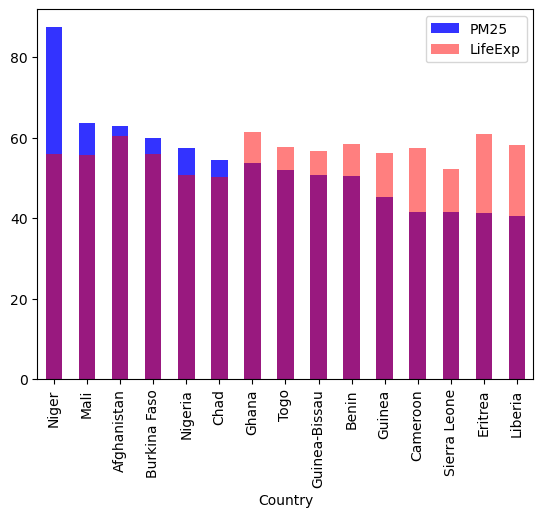

In [15]:
high_PM25_low_life_exp['PM25'].plot.bar(color='blue', alpha=0.8, legend=True)
high_PM25_low_life_exp['LifeExp'].plot.bar(color='red', alpha=0.5, legend=True)

Just for contrast, I want to see if there are any countries with high PM25 and high life expectancy.

In [16]:
# Top 35 countries with worst air pollution
country_PM25 = data.groupby("Country")["PM25"].mean().to_frame()
top_worst_air_quality = country_PM25.sort_values(by="PM25", ascending=False).head(35)

# Top 35 countries with highest life expectancy
country_LifeExp = data.groupby("Country")["LifeExp"].mean().to_frame()
top_highest_life_exp = country_LifeExp.sort_values(by="LifeExp", ascending=False).head(35)

# How many countries are in both lists
high_PM25_high_life_exp = top_worst_air_quality.merge(top_highest_life_exp, on='Country', how='inner')
high_PM25_high_life_exp

,PM25,LifeExp
Country,,
Qatar,88.750759,79.186619
Bahrain,68.056225,78.068714
Kuwait,61.066902,78.078005
United Arab Emirates,43.738868,81.070476


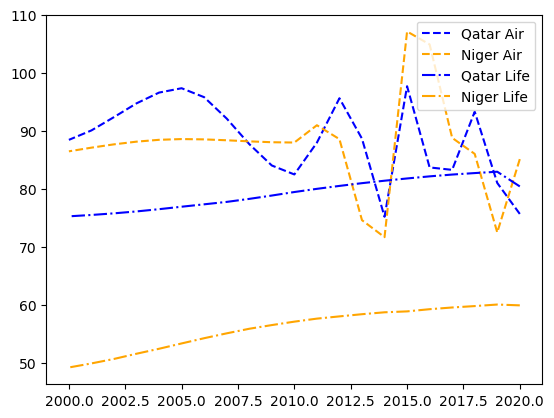

In [17]:
# compare the air quality and life expectancy in the countries with the worst
# air quality but the best and worst life expectancy.
x = data["Year"].unique()
y1 = data.loc[data["Country"] == "Qatar", "PM25"]
y2 = data.loc[data["Country"] == "Niger", "PM25"]
plt.plot(x, y1, label='Qatar Air', linestyle='--', color='blue')
plt.plot(x, y2, label='Niger Air', linestyle='--', color='orange')

y3 = data.loc[data["Country"] == "Qatar", "LifeExp"]
y4 = data.loc[data["Country"] == "Niger", "LifeExp"]
plt.plot(x, y3, label='Qatar Life', linestyle='-.', color='blue')
plt.plot(x, y4, label='Niger Life', linestyle='-.', color='orange')

plt.legend()

Surprisingly, there are a few countries here that have bad air quality and very high life expectancy. This implies that there are probably other variables contributing to life expectancy. Notably, as well, these are all Arab states, located in the same area. Let's look at how GDP and health spending affect life expectancy as well. 

From the correlation done earlier, it seemed like life expectancy was more strongly associated with GDP and health expenditure. Since GDP and health expenditure are almost perfectly correlated (r=0.945956), we can assume for now that countries that have a higher GDP spend more money on healthcare, so only exploring GDP will still give useful insights.

In [18]:
# Do the countries with the worst air quality also have the lowest life expectancy

# Top 35 countries with lowest GDP
country_GDP = data.groupby("Country")["GDP"].mean().to_frame()
top_lowest_GDP = country_GDP.sort_values(by="GDP", ascending=True).head(50)

# Top 35 countries with lowest life expectancy
country_LifeExp = data.groupby("Country")["LifeExp"].mean().to_frame()
top_lowest_life_exp = country_LifeExp.sort_values(by="LifeExp", ascending=True).head(50)

# How many countries are in both lists
low_GDP_low_life_exp = top_lowest_GDP.merge(top_lowest_life_exp, on='Country', how='inner')
low_GDP_low_life_exp

,GDP,LifeExp
Country,,
Burundi,658.788116,56.392667
Central African Republic,812.490185,46.028429
Mozambique,983.452466,55.455381
Niger,1057.454511,55.980619
Liberia,1169.224229,58.097190
Ethiopia,1172.585462,59.052714
Malawi,1285.177760,57.072429
Rwanda,1371.678169,60.588810
Madagascar,1432.972579,61.815476


In [19]:
# Number of countries with low GDP and low life expectancy
low_GDP_low_life_exp_count = len(low_GDP_low_life_exp)

top_highest_life_exp = country_LifeExp.sort_values(by="LifeExp", ascending=False).head(50)
top_highest_GDP = country_GDP.sort_values(by="GDP", ascending=False).head(50)

# Number of countries with low GDP and high life expectancy
low_GDP_high_life_exp = top_lowest_GDP.merge(top_highest_life_exp, on='Country', how='inner')
low_GDP_high_life_exp_count = len(low_GDP_high_life_exp)

# Number of countries with high GDP and low life expectancy
high_GDP_low_life_exp = top_highest_GDP.merge(top_lowest_life_exp, on='Country', how='inner')
high_GDP_low_life_exp_count = len(high_GDP_low_life_exp)

# Number of countries with high GDP and high life expectancy
high_GDP_high_life_exp = top_highest_GDP.merge(top_highest_life_exp, on='Country', how='inner')
high_GDP_high_life_exp_count = len(high_GDP_high_life_exp)

print(f"Low GDP, low life expectancy: {low_GDP_low_life_exp_count}")
print(f"Low GDP, high life expectancy: {low_GDP_high_life_exp_count}")
print(f"High GDP, low life expectancy: {high_GDP_low_life_exp_count}")
print(f"High GDP, high life expectancy: {high_GDP_high_life_exp_count}")

Low GDP, low life expectancy: 40
Low GDP, high life expectancy: 0
High GDP, low life expectancy: 1
High GDP, high life expectancy: 40


In [20]:
high_GDP_low_life_exp

,GDP,LifeExp
Country,,
Equatorial Guinea,20965.191359,58.186667


Since Equatorial Guinea is an odd one out, let's dive further into the data from this country.

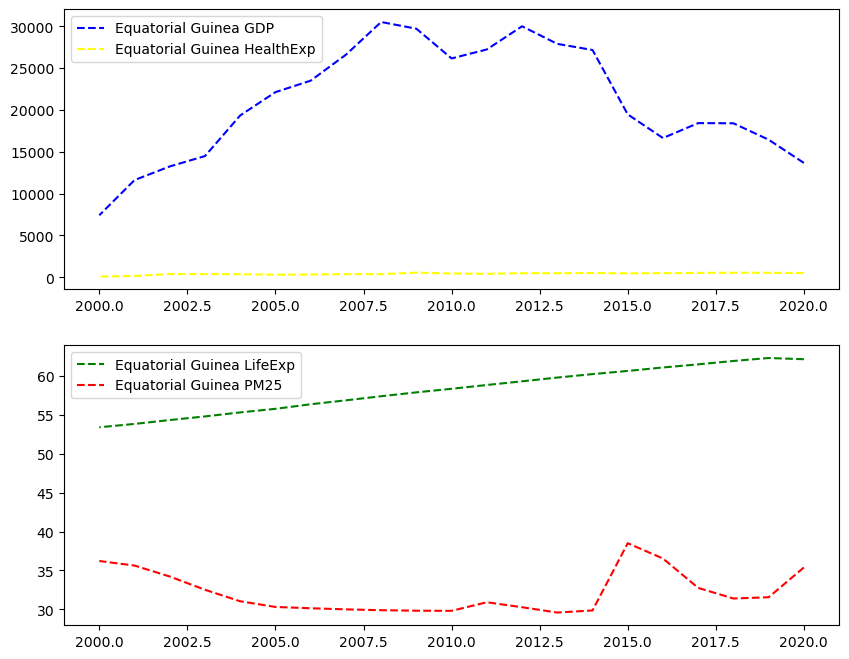

In [22]:
x = data["Year"].unique()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

y5 = data.loc[data["Country"] == "Equatorial Guinea", "GDP"]
y6 = data.loc[data["Country"] == "Equatorial Guinea", "LifeExp"]
y7 = data.loc[data["Country"] == "Equatorial Guinea", "PM25"]
y8 = data.loc[data["Country"] == "Equatorial Guinea", "HealthExp"]


ax1.plot(x, y5, label='Equatorial Guinea GDP', linestyle='--', color='blue')
ax1.plot(x, y8, label='Equatorial Guinea HealthExp', linestyle='--', color='yellow')
ax1.legend()

ax2.plot(x, y6, label='Equatorial Guinea LifeExp', linestyle='--', color='green')
ax2.plot(x, y7, label='Equatorial Guinea PM25', linestyle='--', color='red')
ax2.legend()

In [23]:
country_GDP__healthExp = data.groupby("Country")[["GDP", "HealthExp"]].mean()
country_GDP__healthExp.sort_values(by="GDP", ascending=False).head(50)

,GDP,HealthExp
Country,,
Qatar,119601.410928,2839.759259
Luxembourg,89968.872299,5349.172332
United Arab Emirates,87079.362965,2757.927422
Brunei Darussalam,75872.520032,1702.287256
Singapore,73790.221099,2782.650377
Kuwait,67550.649712,1967.801875
San Marino,58165.352157,3689.774562
Norway,56358.134753,5205.929611
Switzerland,54872.328710,5760.161984


Among the 50 countries with the lowest GDP, 40 also rank among those with the lowest life expectancy. Conversely, 40 of the 50 highest-GDP countries have high life expectancy. Only Equatorial Guinea is an exception to this group. 

A closer look at Equatorial Guinea shows that life expectancy is shaped by multiple factors: GDP, health expenditure, and air quality can each play a role. Despite having a relatively high GDP, Equatorial Guinea has low life expectancy. Its air quality is better than many neighbouring countries, which rules that out as the primary driver. However, of all 50 high-GDP countries, Equatorial Guinea spends the least on health expenditure, implying that is the reason for it's low life expectancy.

## Hypothesis Testing

<Axes: >

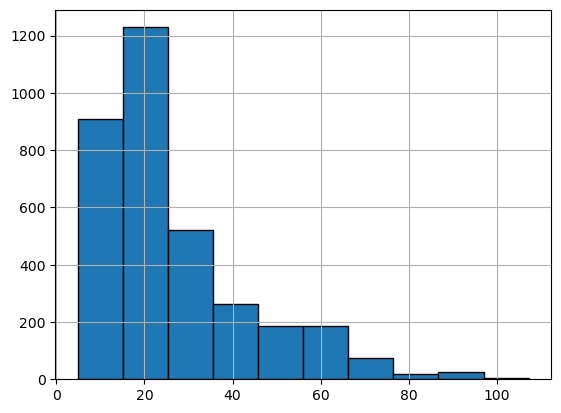

In [28]:
data['PM25'].hist(edgecolor='black')

Since the histogram of air pollution is right skewed, median will be used as a measure of center.

### The permutation test at 5% significance:
Null Hypothesis: There is no difference between the mean life expectancy in countries with high PM2.5 and the mean life expectancy in countries with low PM2.5. Any observed difference in the sample is due to random chance.

Alternative Hypothesis: The mean life expectancy in countries with high PM2.5 is lower than the mean life expectancy in countries with low PM2.5.

Test Statistic: The test statistic is the difference between the mean life expectancy in countries with low PM2.5 and the mean life expectancy in countries with high PM2.5.

In [42]:
high_PM25 = data[data['PM25'] > data['PM25'].median()]['LifeExp']
low_PM25  = data[data['PM25'] <= data['PM25'].median()]['LifeExp']

# observed difference in means
observed_diff = low_PM25.mean() - high_PM25.mean()
print(f"Observed difference in means: {np.round(observed_diff, 2)} years")


Observed difference in means: 7.15 years


In [31]:
def simulate_one_difference(tbl):
    # simulates one value of the test statistic under the null hypothesis.
    shuffled_labels = tbl['high_PM25_group'].sample(frac=1, replace=False).values
    shuffled_table = tbl[['LifeExp']].copy()
    shuffled_table['shuffled_label'] = shuffled_labels
    grouped = shuffled_table.groupby('shuffled_label')['LifeExp']
    simulated_diff = grouped.mean().loc[True] - grouped.mean().loc[False]
    return simulated_diff

In [43]:
# create new table for permutation test and add a 'high_PM25_group' column
permutation_df = data[['LifeExp', 'PM25']].copy()
permutation_df['high_PM25_group'] = permutation_df['PM25'] > permutation_df['PM25'].median()

repetitions = 5000
differences = []

# do the permutation test
for i in np.arange(repetitions):
    simulated = simulate_one_difference(permutation_df)
    differences.append(simulated)

print(f"First 10 simulated differences: {np.round(differences[:10], 2)}")

# calculate p value
num_greater = 0
for value in differences:
    if value >= observed_diff:
        num_greater += 1

p_value = num_greater / len(differences)
print(f"\nThe p-value is: {p_value}")

First 10 simulated differences: [ 0.2  -0.05 -0.14 -0.47 -0.05 -0.06 -0.28  0.05 -0.34  0.4 ]

The p-value is: 0.0


Our p-value is 0.0. Compared to the significance level of 0.05, this p-value is smaller. Therefore, we reject the null hypothesis. This means that the mean life expectancy in countries with high PM2.5 is lower than the mean life expectancy in countries with low PM2.5.